# Week 13

In [1]:
from misc import *
import constant

In [2]:
# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df = df[df["Kplus_isMuon"] == False]

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass [$\\mathrm{MeV}/c^2$]', ylabel='Candidates / (4 $\\mathrm{MeV}/c^2$)'>)

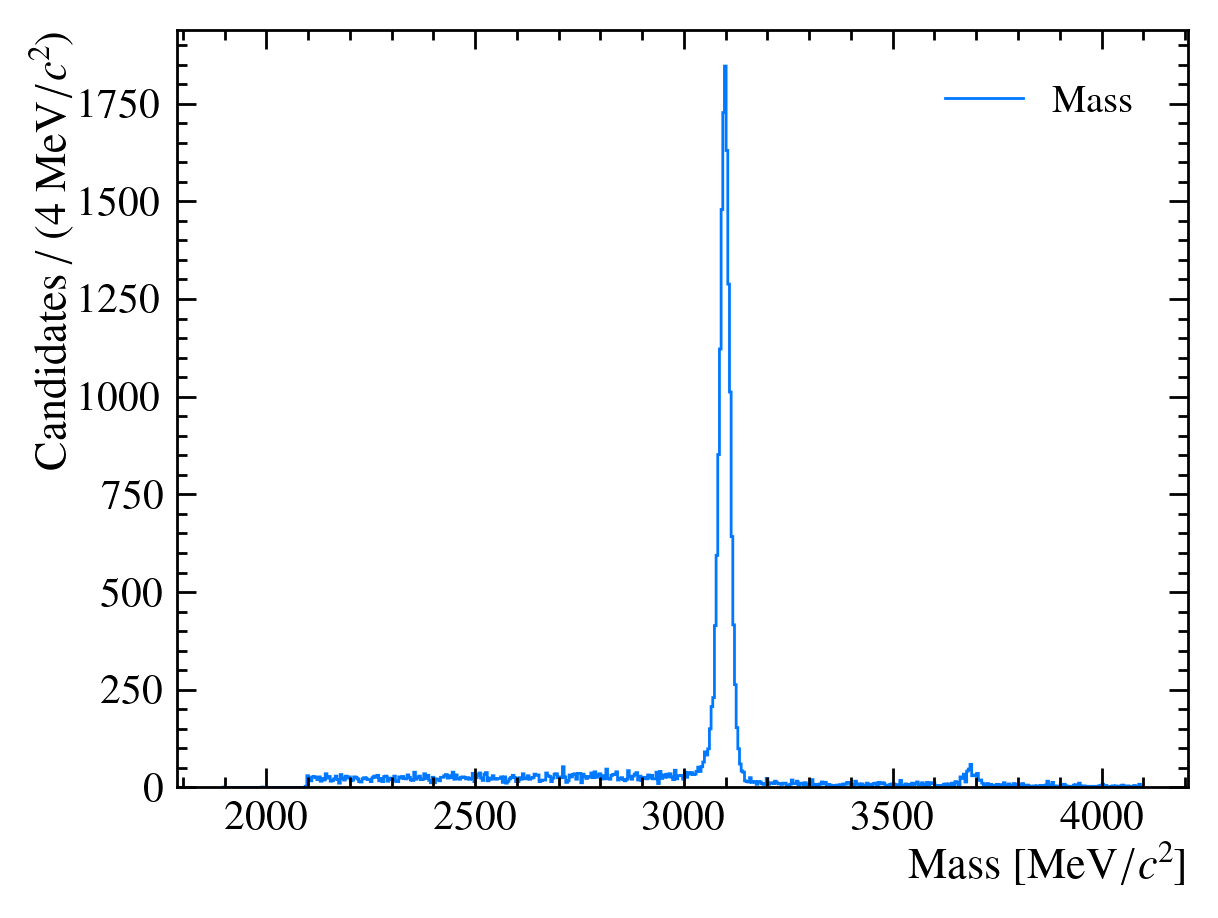

In [3]:
histogram_fig(
    [HistogramPlot(df["J_psi_1S_M"], "Mass", bins = 4)],
    False,
    xlabel="Mass",
    unit_tex=r"\mathrm{MeV}/c^2"
)

In [4]:
df = df[(constant.JPSI_MASS-50 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+50)]

In [5]:
fitted_Bplus_PV_df = df[df["Bplus_OWNPV_X"] > -900]
unfitted_Bplus_PV_df = df[df["Bplus_OWNPV_X"] < -900]

print(len(fitted_Bplus_PV_df))
print(len(unfitted_Bplus_PV_df))

6235
8350


Flight distance of candidates with a determined PV

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{\\mu m}$', ylabel='Candidates / (4 $\\mathrm{\\mu m}$)'>)

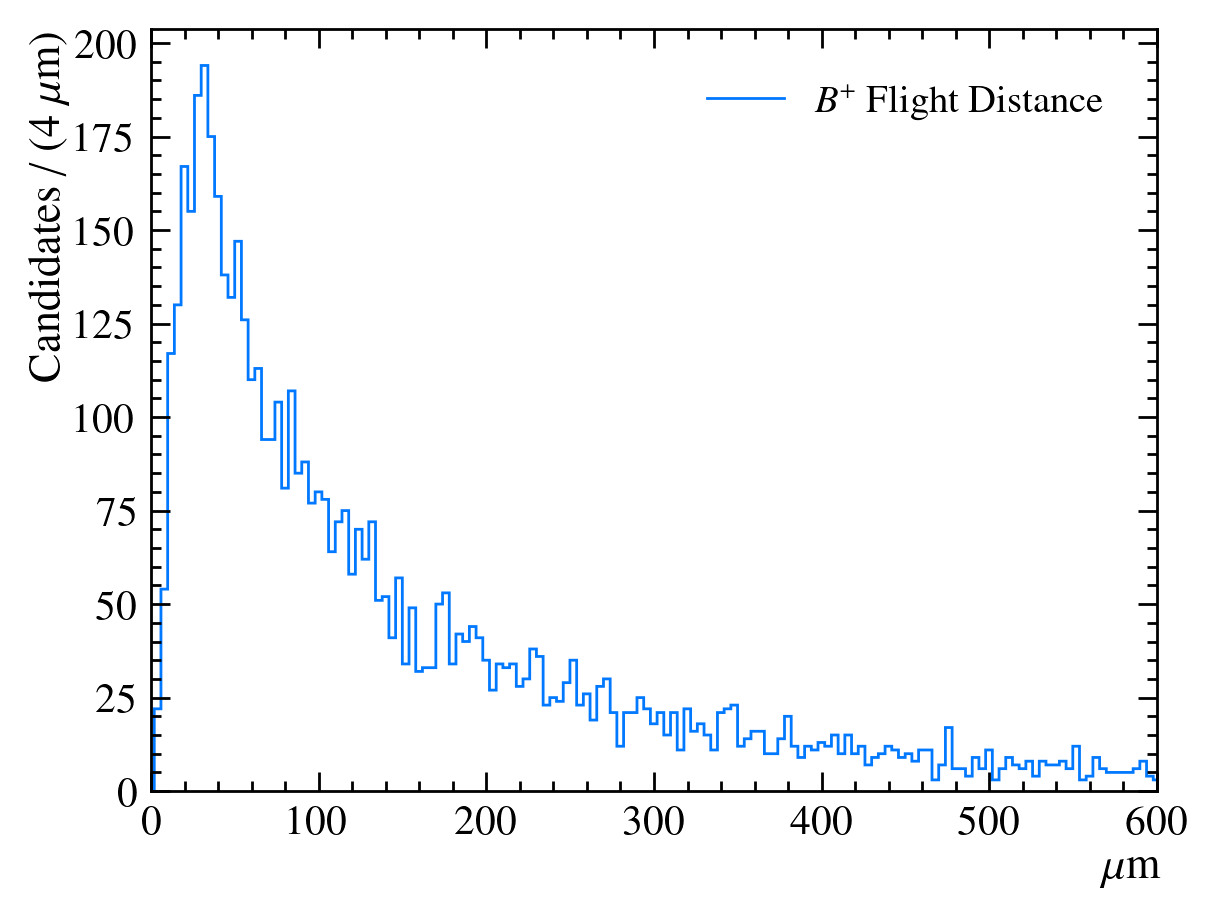

In [6]:
histogram_fig(
    [HistogramPlot(fitted_Bplus_PV_df["Bplus_FD_OWNPV"]*1000, "$B^+$ Flight Distance", bins = 4)],
    False,
    xlim=[0,600],
    unit_tex=r"\mathrm{\mu m}"
)

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{MeV}/c^2$', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

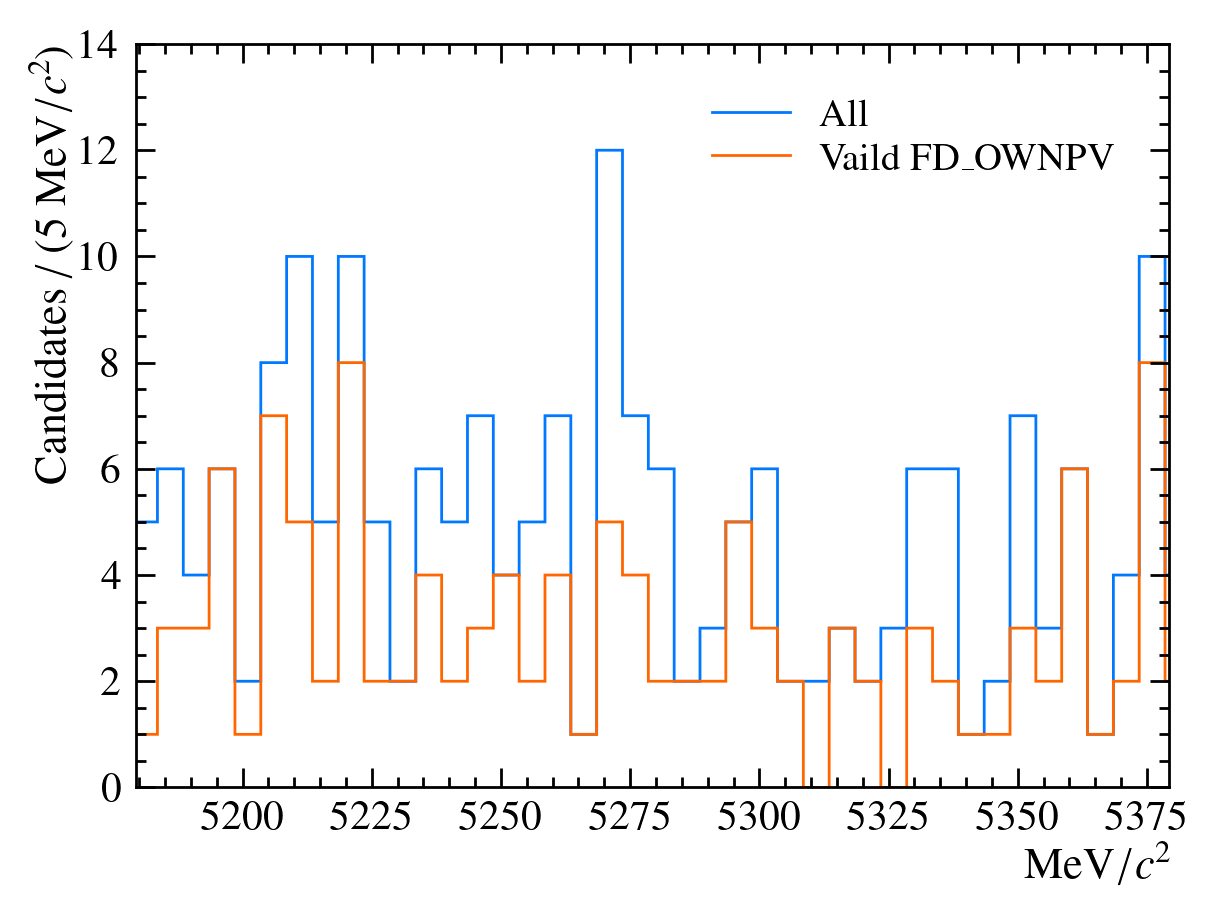

In [7]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], "All", bins=5),
        HistogramPlot(fitted_Bplus_PV_df["Bplus_M"], "Vaild FD_OWNPV", bins=first.bin_edges),
    ],
    False,
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    unit_tex=r"\mathrm{MeV}/c^2",
    ylim=[0,14]
)

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{MeV}/c^2$', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

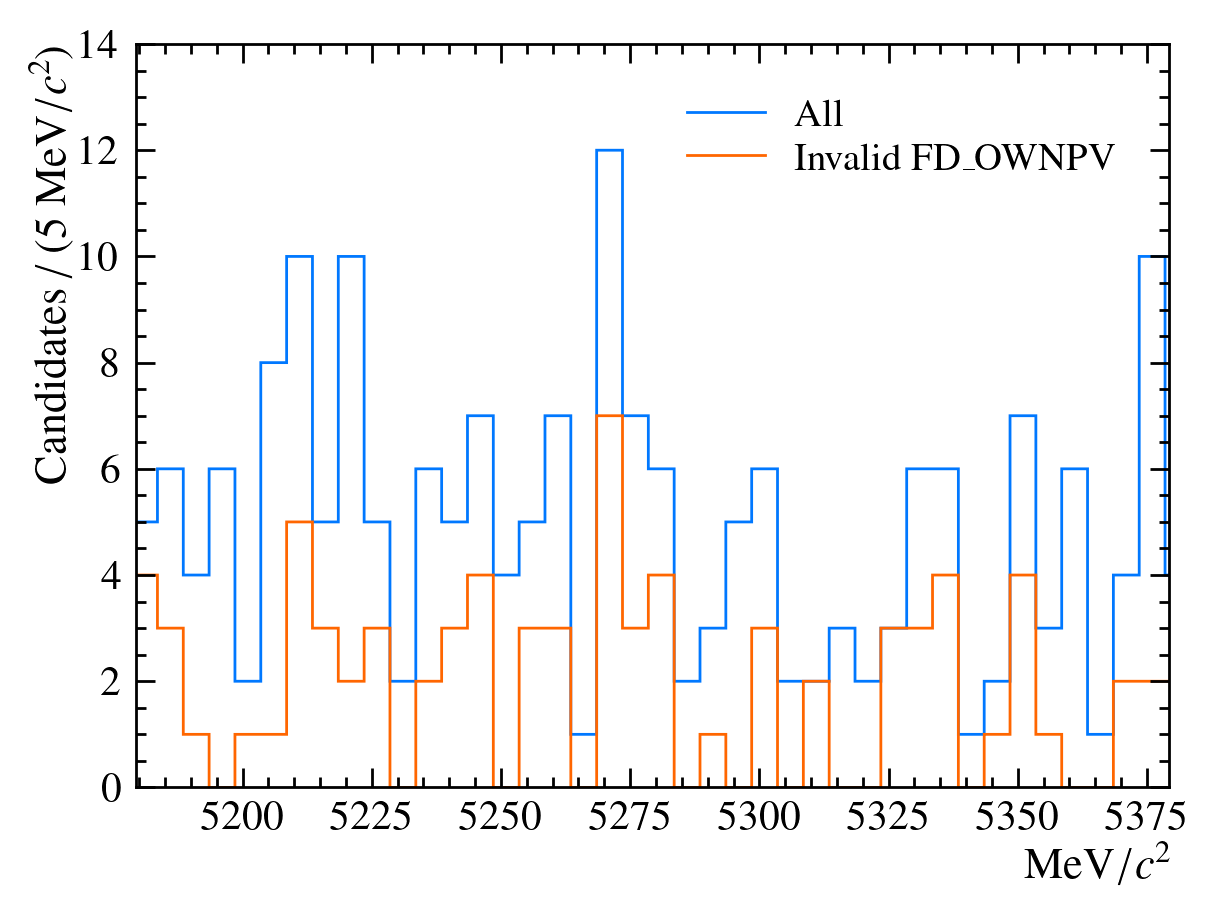

In [8]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], "All", bins=5),
        HistogramPlot(unfitted_Bplus_PV_df["Bplus_M"], "Invalid FD_OWNPV", bins=first.bin_edges),

    ],
    False,
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    unit_tex=r"\mathrm{MeV}/c^2",
    ylim=[0,14]
)

In [9]:
# histogram_fig(
#     [HistogramPlot(df["Bplus_ENDVERTEX_CHI2"], "$B^+$ End Vertex")],
#     "figures/week13/Bplus_ENDVTX_CHI2.png",
#     xlim=[0,10],
#     xlabel=r"$\chi^2$"
# )

In [10]:
# histogram_fig(
#     [HistogramPlot(fitted_Bplus_PV_df["Bplus_ENDVERTEX_CHI2"], "PV determined"),
#      HistogramPlot(unfitted_Bplus_PV_df["Bplus_ENDVERTEX_CHI2"], "PV undetermined")],
#     "figures/week13/Bplus_ENDVTX_CHI2_PVs.png",
#     xlim=[0,10],
#     xlabel=r"$\chi^2$",
#     ylim=[0,1000]
# )

# PV $\chi^2$

Histogram saved to figures/week13/Bplus_ENDVTX_CHI2_PVs.png


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$\\chi^2$', ylabel='Candidate Density'>)

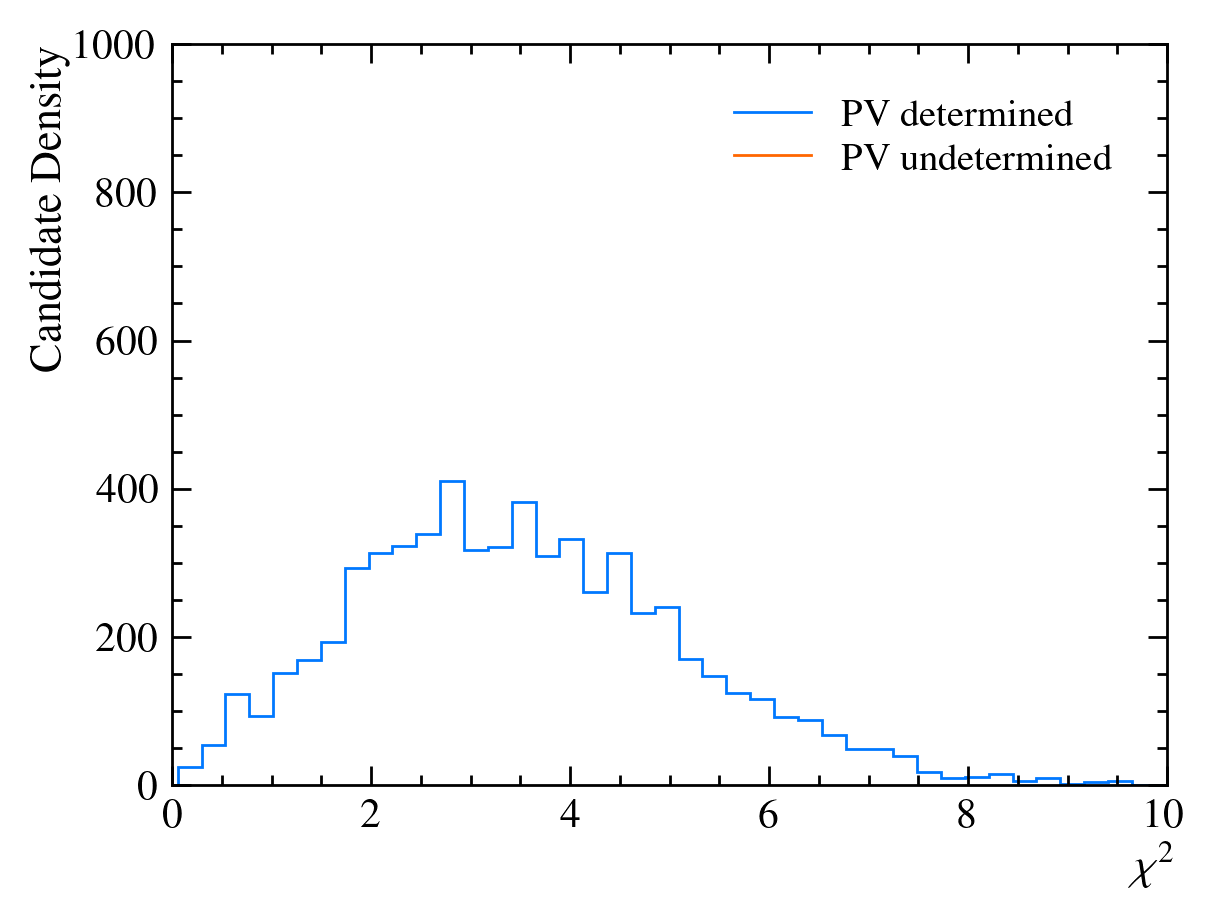

In [11]:
histogram_fig(
    [HistogramPlot(fitted_Bplus_PV_df["Bplus_OWNPV_CHI2"], "PV determined"),
     HistogramPlot(unfitted_Bplus_PV_df["Bplus_OWNPV_CHI2"], "PV undetermined")],
    "figures/week13/Bplus_ENDVTX_CHI2_PVs.png",
    xlim=[0,10],
    xlabel=r"$\chi^2$",
    ylim=[0,1000]
)

# Velo Tracks for (un)determined PV

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Velo Tracks', ylabel='Candidate Density'>)

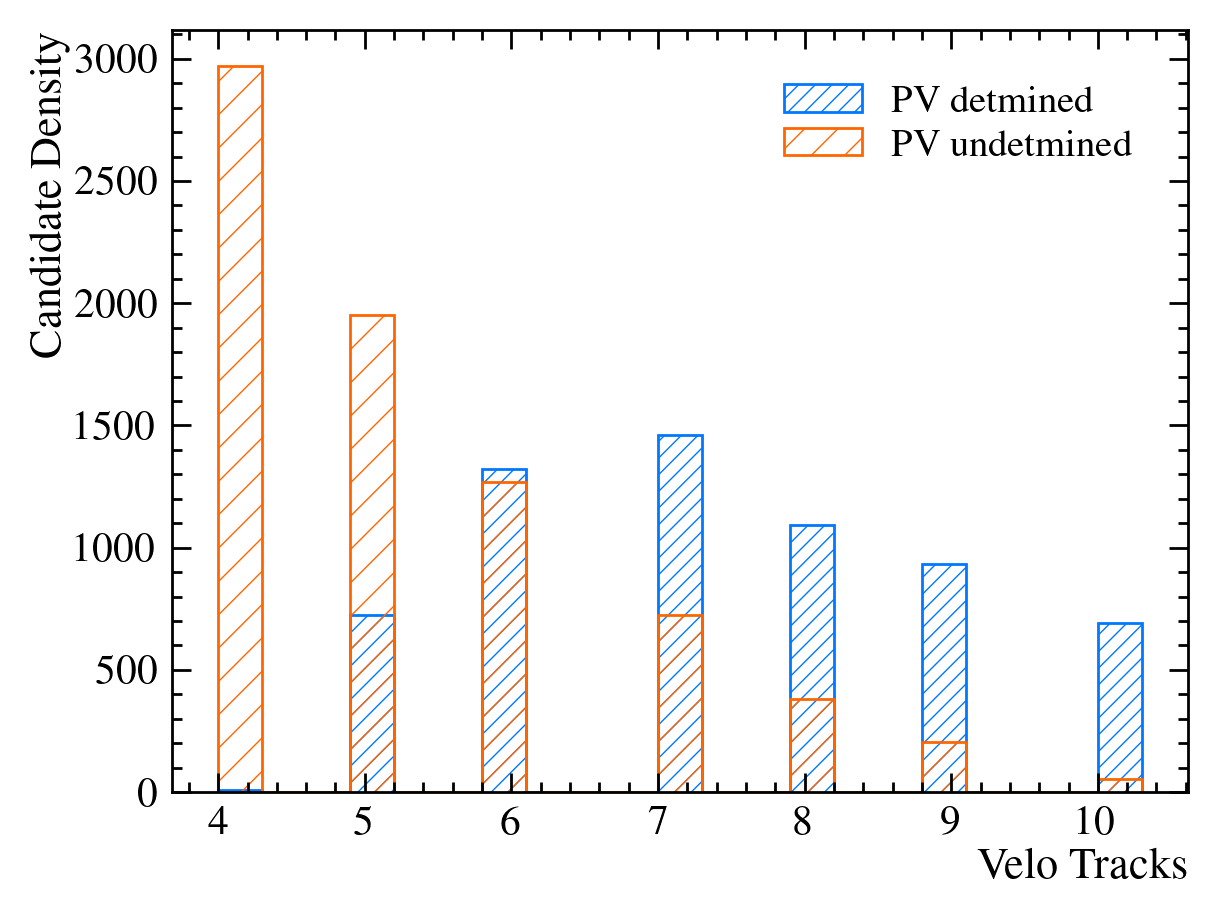

In [12]:
histogram_fig(
    [
        first := HistogramPlot(
            fitted_Bplus_PV_df["nVeloTracks"], "PV detmined", bins=0.3, hatch="//"
        ),
        HistogramPlot(
            unfitted_Bplus_PV_df["nVeloTracks"],
            "PV undetmined",
            bins=first.bin_edges,
            hatch="/",
        ),
    ],
    False,
    # xlim=[3,11],
    xlabel=r"Velo Tracks",
)

# End Vetex quality

Histogram not saved to file
Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass [$\\mathrm{MeV}/c^2$]', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

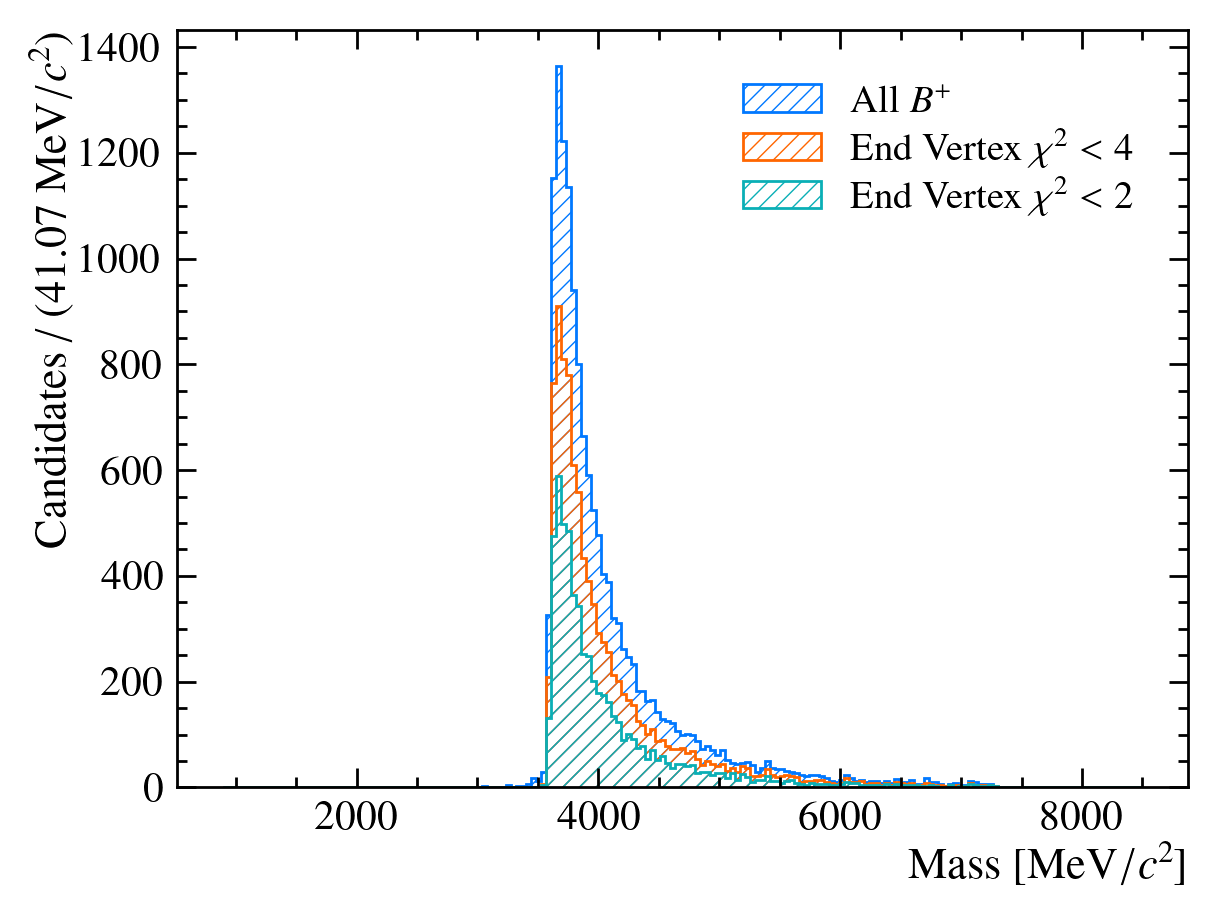

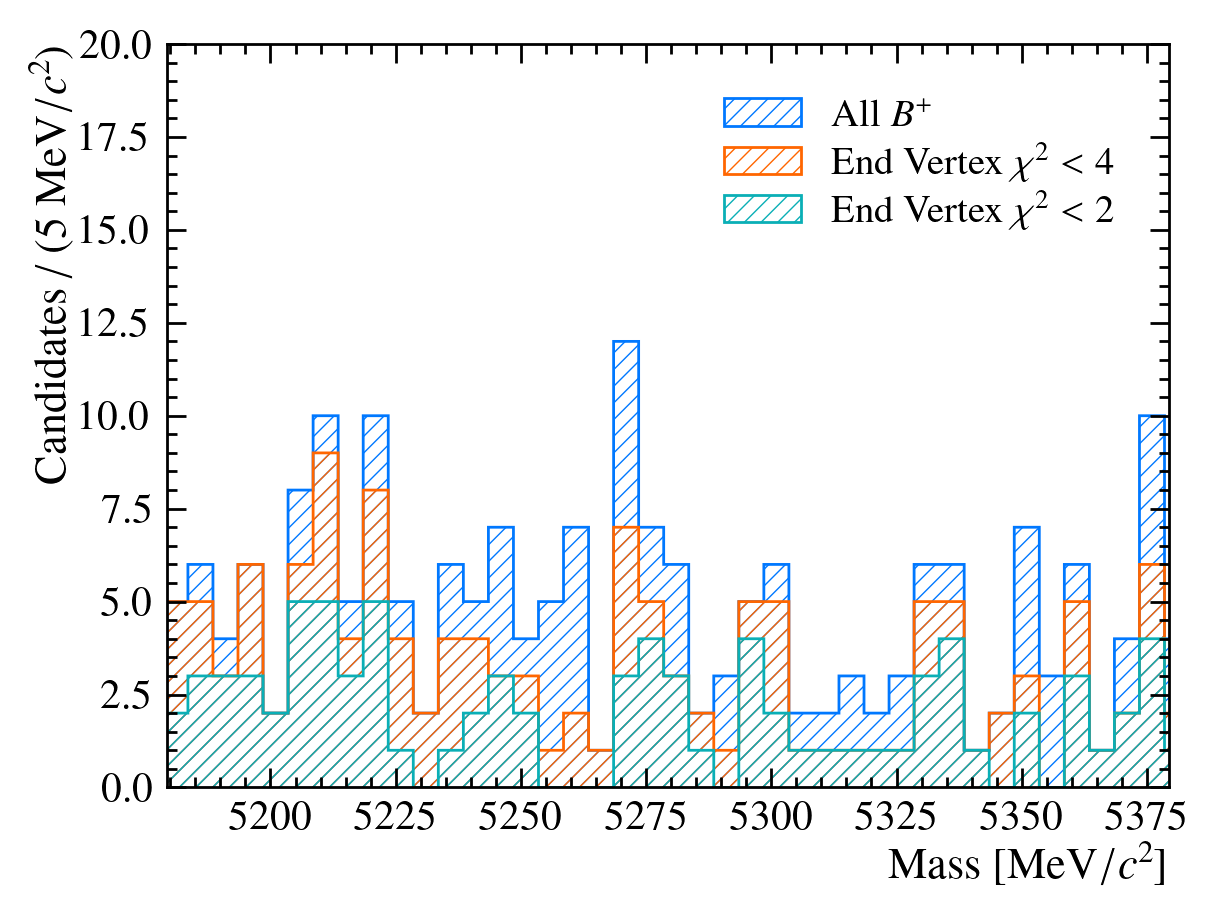

In [13]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], r"All $B^+$", hatch="//"),
        HistogramPlot(
            df[df["Bplus_ENDVERTEX_CHI2"] < 4]["Bplus_M"],
            r"End Vertex $\chi^2 < 4$",
            bins=first.bin_edges,
            hatch="//"
        ),
        HistogramPlot(
            df[df["Bplus_ENDVERTEX_CHI2"] < 2]["Bplus_M"],
            r"End Vertex $\chi^2 < 2$",
            bins=first.bin_edges,
            hatch="//"
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    # xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    # ylim=[0, 20],
)

histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], r"All $B^+$", bins=5, hatch="//"),
        HistogramPlot(
            df[df["Bplus_ENDVERTEX_CHI2"] < 4]["Bplus_M"],
            r"End Vertex $\chi^2 < 4$",
            bins=first.bin_edges,
            hatch="//"
        ),
        HistogramPlot(
            df[df["Bplus_ENDVERTEX_CHI2"] < 2]["Bplus_M"],
            r"End Vertex $\chi^2 < 2$",
            bins=first.bin_edges,
            hatch="//"
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    ylim=[0, 20],
)

# High Multiplicity

Histogram not saved to file
Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass [$\\mathrm{MeV}/c^2$]', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

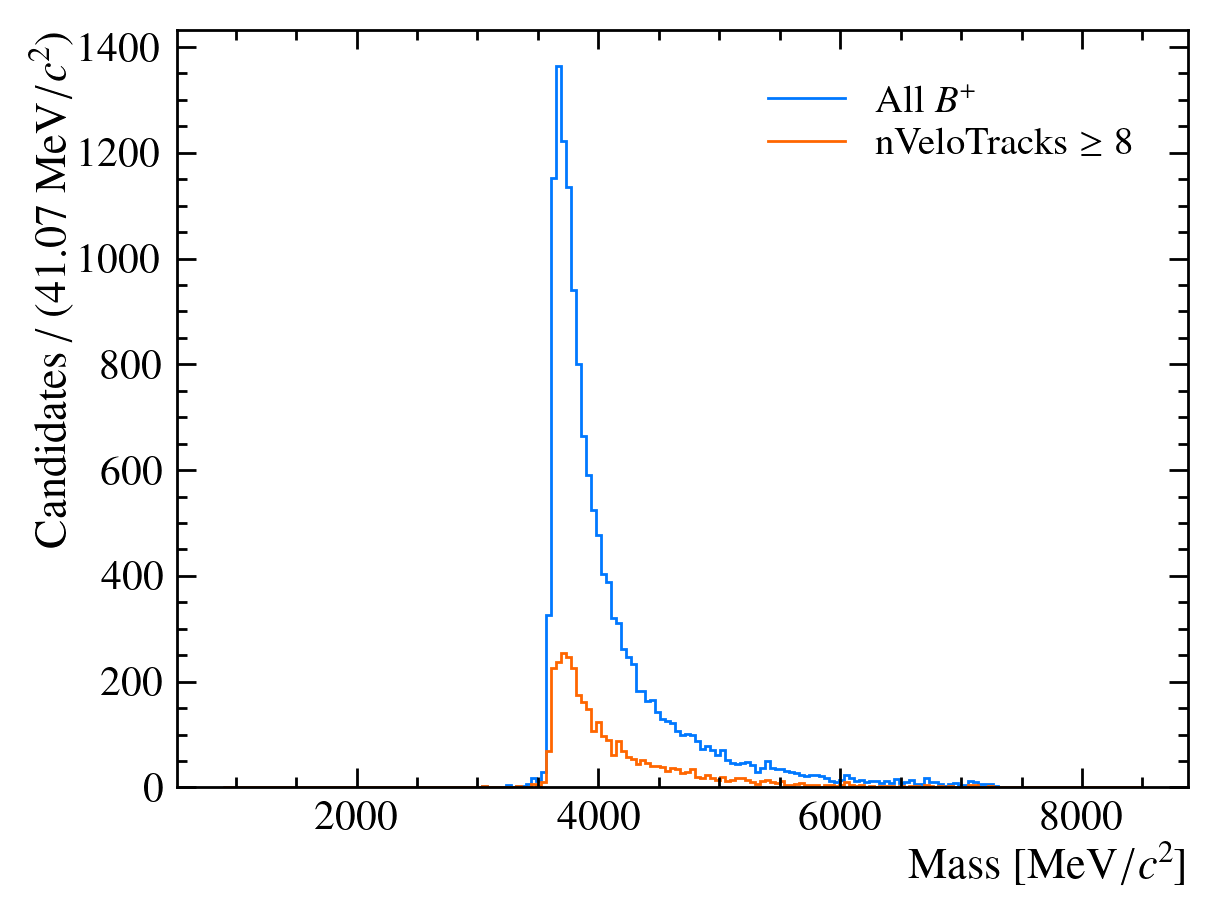

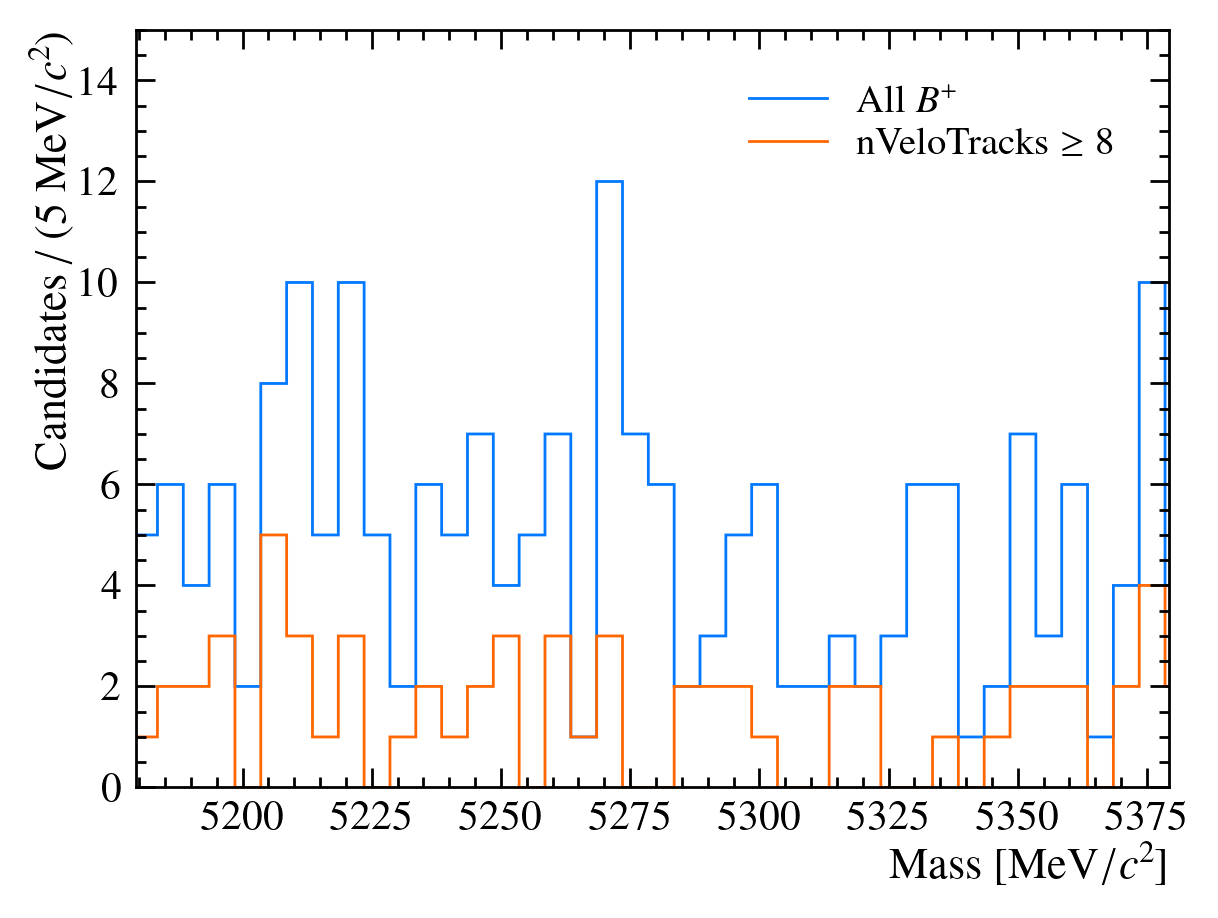

In [14]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], r"All $B^+$"),
        HistogramPlot(
            df[df["nVeloTracks"] > 7]["Bplus_M"],
            r"nVeloTracks $\geq 8$",
            bins=first.bin_edges,
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
)

histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], r"All $B^+$", bins=5),
        HistogramPlot(
            df[df["nVeloTracks"] > 7]["Bplus_M"],
            r"nVeloTracks $\geq 8$",
            bins=first.bin_edges,
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    ylim=[0, 15],
)

# High $p_T$

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Transverse Momentum $p_T$ [$\\mathrm{MeV}/c$]', ylabel='Candidates / (98.12 $\\mathrm{MeV}/c$)'>)

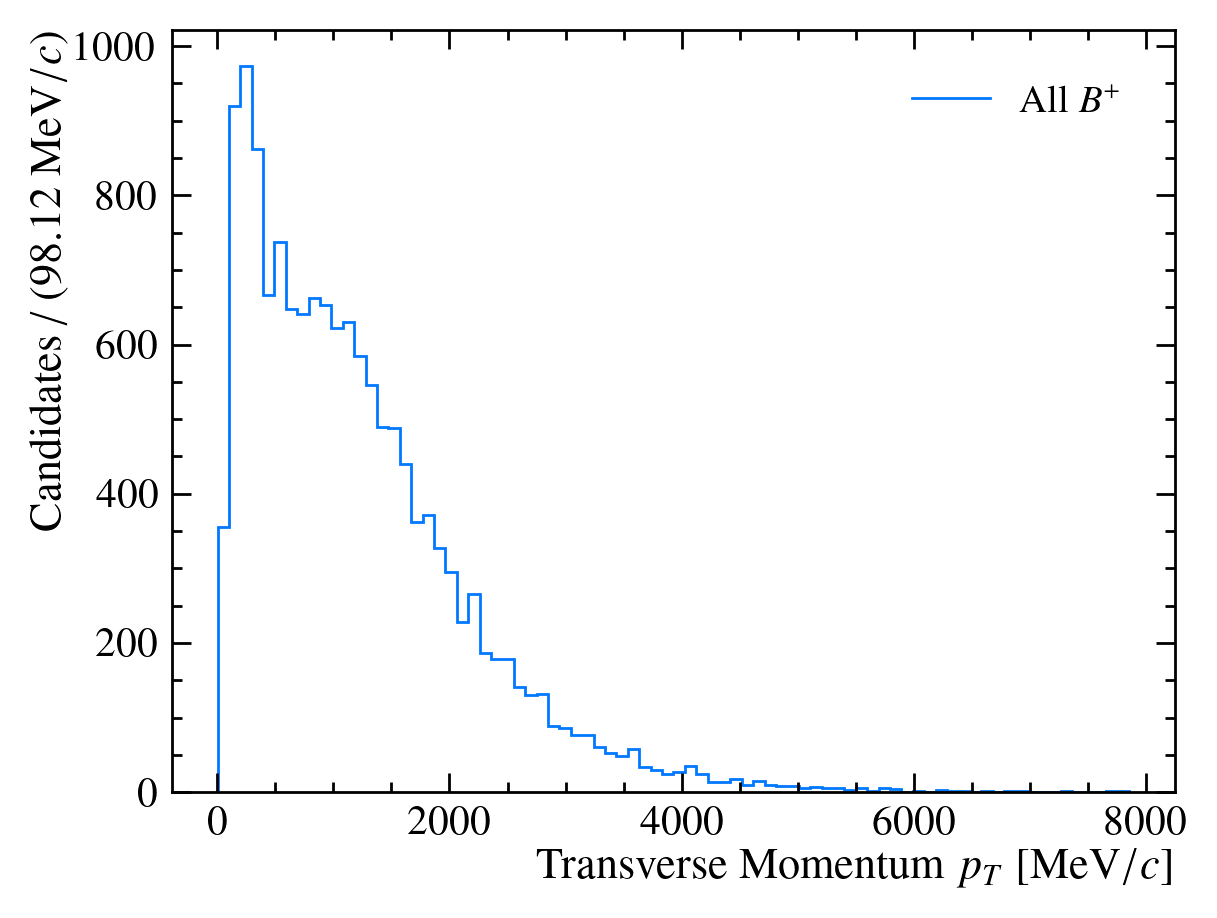

In [15]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_PT"], r"All $B^+$"),
    ],
    False,
    xlabel=r"Transverse Momentum $p_T$",
    unit_tex=r"\mathrm{MeV}/c",
    # xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    # ylim=[0, 20],
)

Histogram not saved to file
Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass [$\\mathrm{MeV}/c^2$]', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

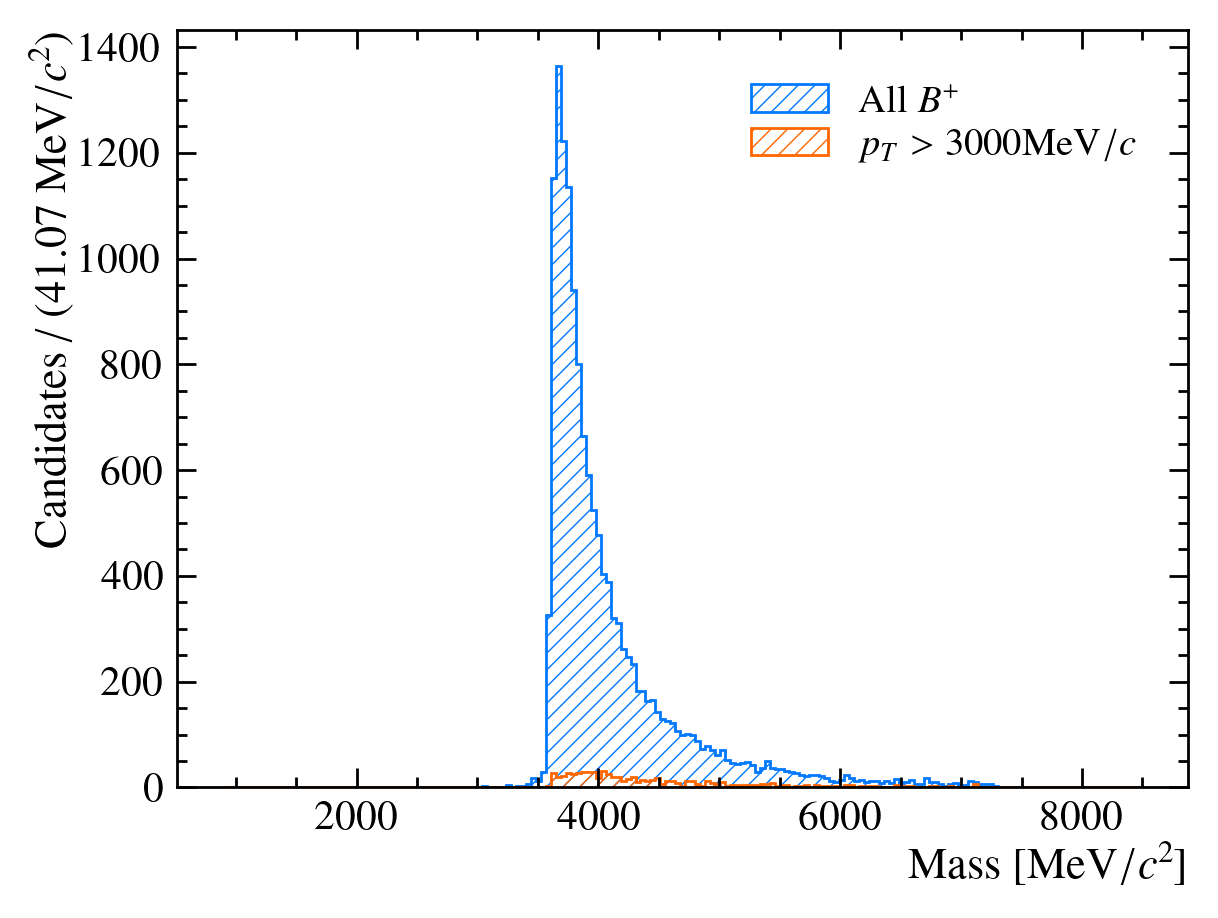

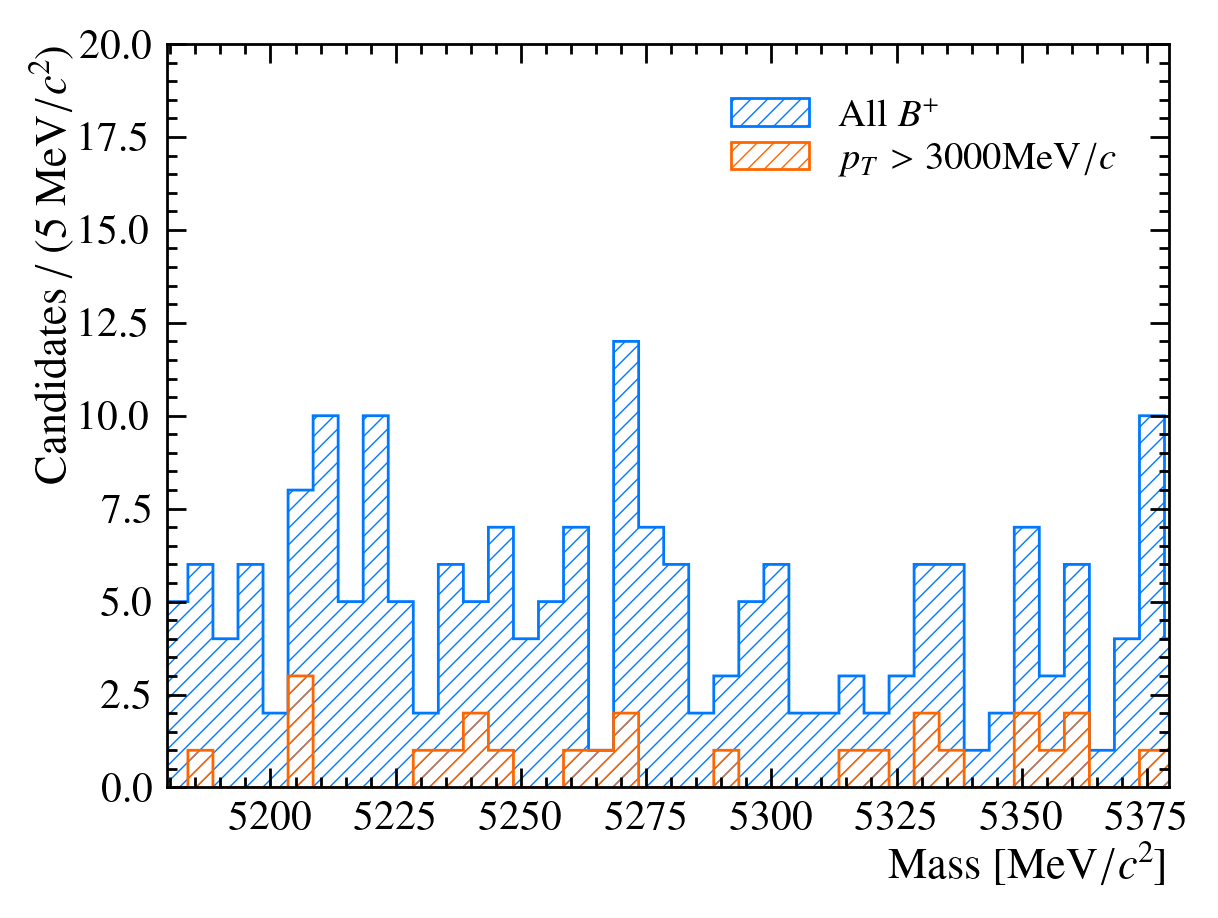

In [16]:
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], r"All $B^+$", hatch="//"),
        HistogramPlot(
            df[df["Bplus_PT"] > 3000]["Bplus_M"],
            r"$p_T > 3000 \mathrm{MeV}/c$",
            bins=first.bin_edges,
            hatch="//"
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
)
histogram_fig(
    [
        first := HistogramPlot(df["Bplus_M"], r"All $B^+$", bins=5, hatch="//"),
        HistogramPlot(
            df[df["Bplus_PT"] > 3000]["Bplus_M"],
            r"$p_T > 3000 \mathrm{MeV}/c$",
            bins=first.bin_edges,
            hatch="//"
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    ylim=[0, 20],
)

# Lifetime

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='$B^+$ Lifetime [$\\mathrm{ps}$]', ylabel='Candidates / (0.00481 $\\mathrm{ps}$)'>)

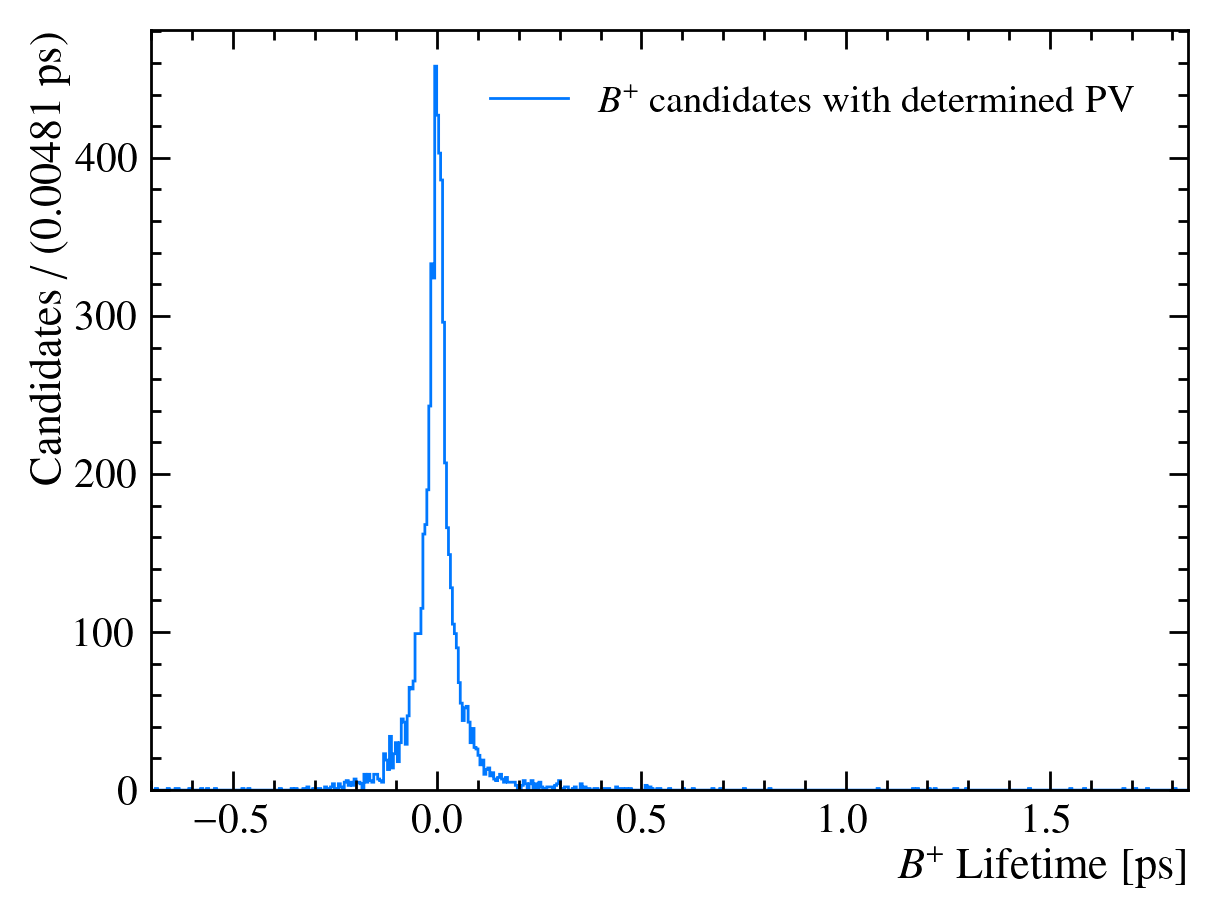

In [17]:
histogram_fig(
    [
        first := HistogramPlot(fitted_Bplus_PV_df["Bplus_BPVLTIME"]*1000, r"$B^+$ candidates with determined PV"),
    ],
    False,
    xlabel=r"$B^+$ Lifetime",
    # unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[-0.7, constant.BPLUS_LIFETIME*1000 + 0.2],
    unit_tex=r"\mathrm{ps}"
)

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>,
 <Axes: xlabel='Mass [$\\mathrm{MeV}/c^2$]', ylabel='Candidates / (5 $\\mathrm{MeV}/c^2$)'>)

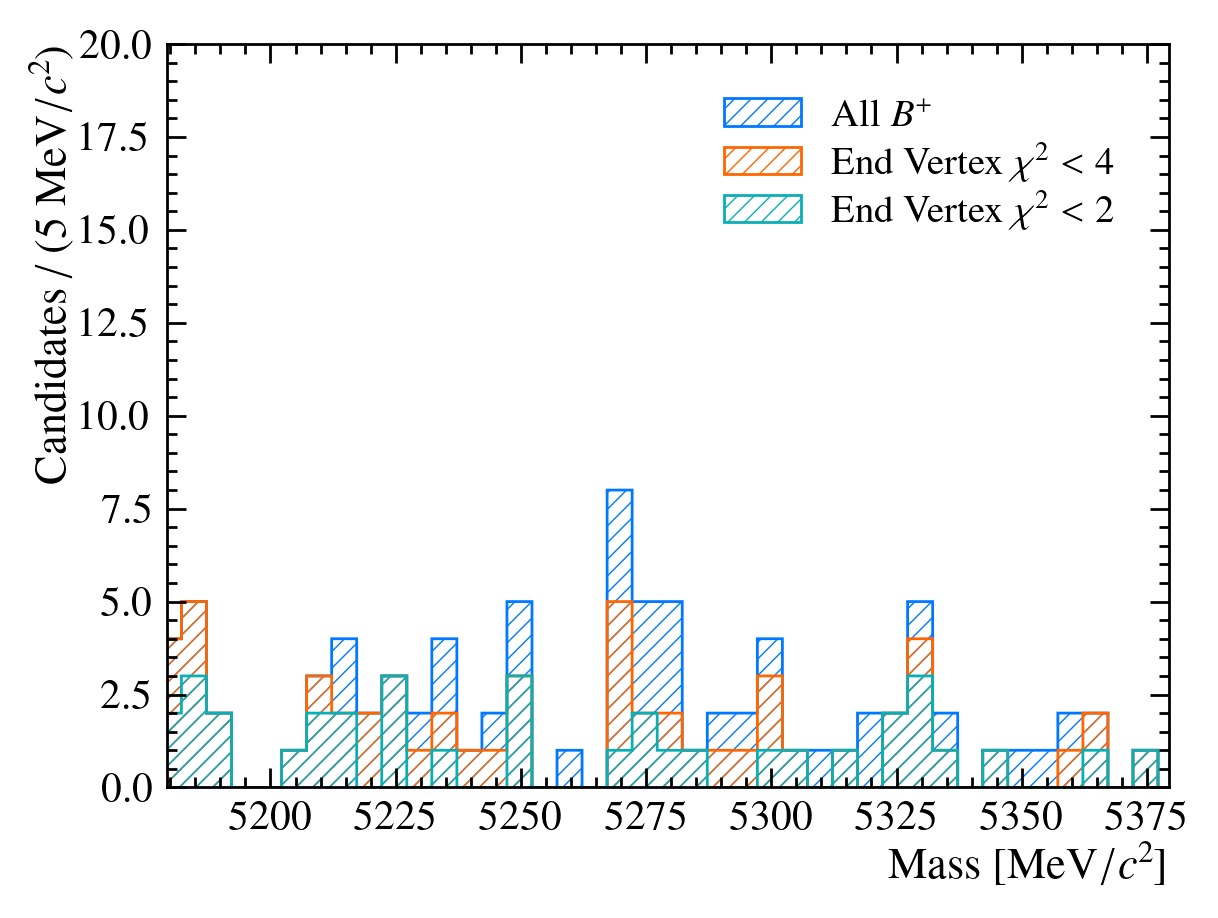

In [18]:
LTRACK3_FILE_PATH = "/dice/projects/LHCb/PbPb_MSCi/isMuon_PbPb_B2JpsiK/isMuon.root"
df_3ltracks = load_root(LTRACK3_FILE_PATH, DEFAULT_TREE_NAME)


histogram_fig(
    [
        first := HistogramPlot(df_3ltracks["Bplus_M"], r"All $B^+$", bins=5, hatch="//"),
        HistogramPlot(
            df_3ltracks[df_3ltracks["Bplus_ENDVERTEX_CHI2"] < 4]["Bplus_M"],
            r"End Vertex $\chi^2 < 4$",
            bins=first.bin_edges,
            hatch="//"
        ),
        HistogramPlot(
            df_3ltracks[df_3ltracks["Bplus_ENDVERTEX_CHI2"] < 2]["Bplus_M"],
            r"End Vertex $\chi^2 < 2$",
            bins=first.bin_edges,
            hatch="//"
        ),
    ],
    False,
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    ylim=[0, 20],
)